<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/2D_Truss_Heatmap_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
!uv pip install -q numpy pandas matplotlib cupy-cuda12x

Install note: !uv pip install -q numpy pandas matplotlib cupy-cuda12x
Backend: CuPy GPU

Element diagnostics
 Member Nodes  Length (m)  Angle (deg)  Axial force (N)  Stress (MPa)  Strain (microstrain)  Utilization (-)  Safety factor (-)       State
      0   0-1     2.00000      0.00000        296.54800       0.05931               0.28243          0.00024         4215.16921     Tension
      1   1-2     1.80278    123.69007       -534.60951      -0.10692              -0.50915          0.00043         2338.15519 Compression
      2   0-2     1.80278     56.30993       -534.60951      -0.10692              -0.50915          0.00043         2338.15519 Compression

Node diagnostics
 Node  x (m)  y (m)  Ux (mm)  Uy (mm)  |u| (mm)  Applied Fx (N)  Applied Fy (N)  Reaction Rx (N)  Reaction Ry (N)                        Support
    0    0.0    0.0  0.00000  0.00000   0.00000             0.0           0.000              0.0          444.822   Ux fixed=True, Uy fixed=True
    1    2.0    0.0  0.

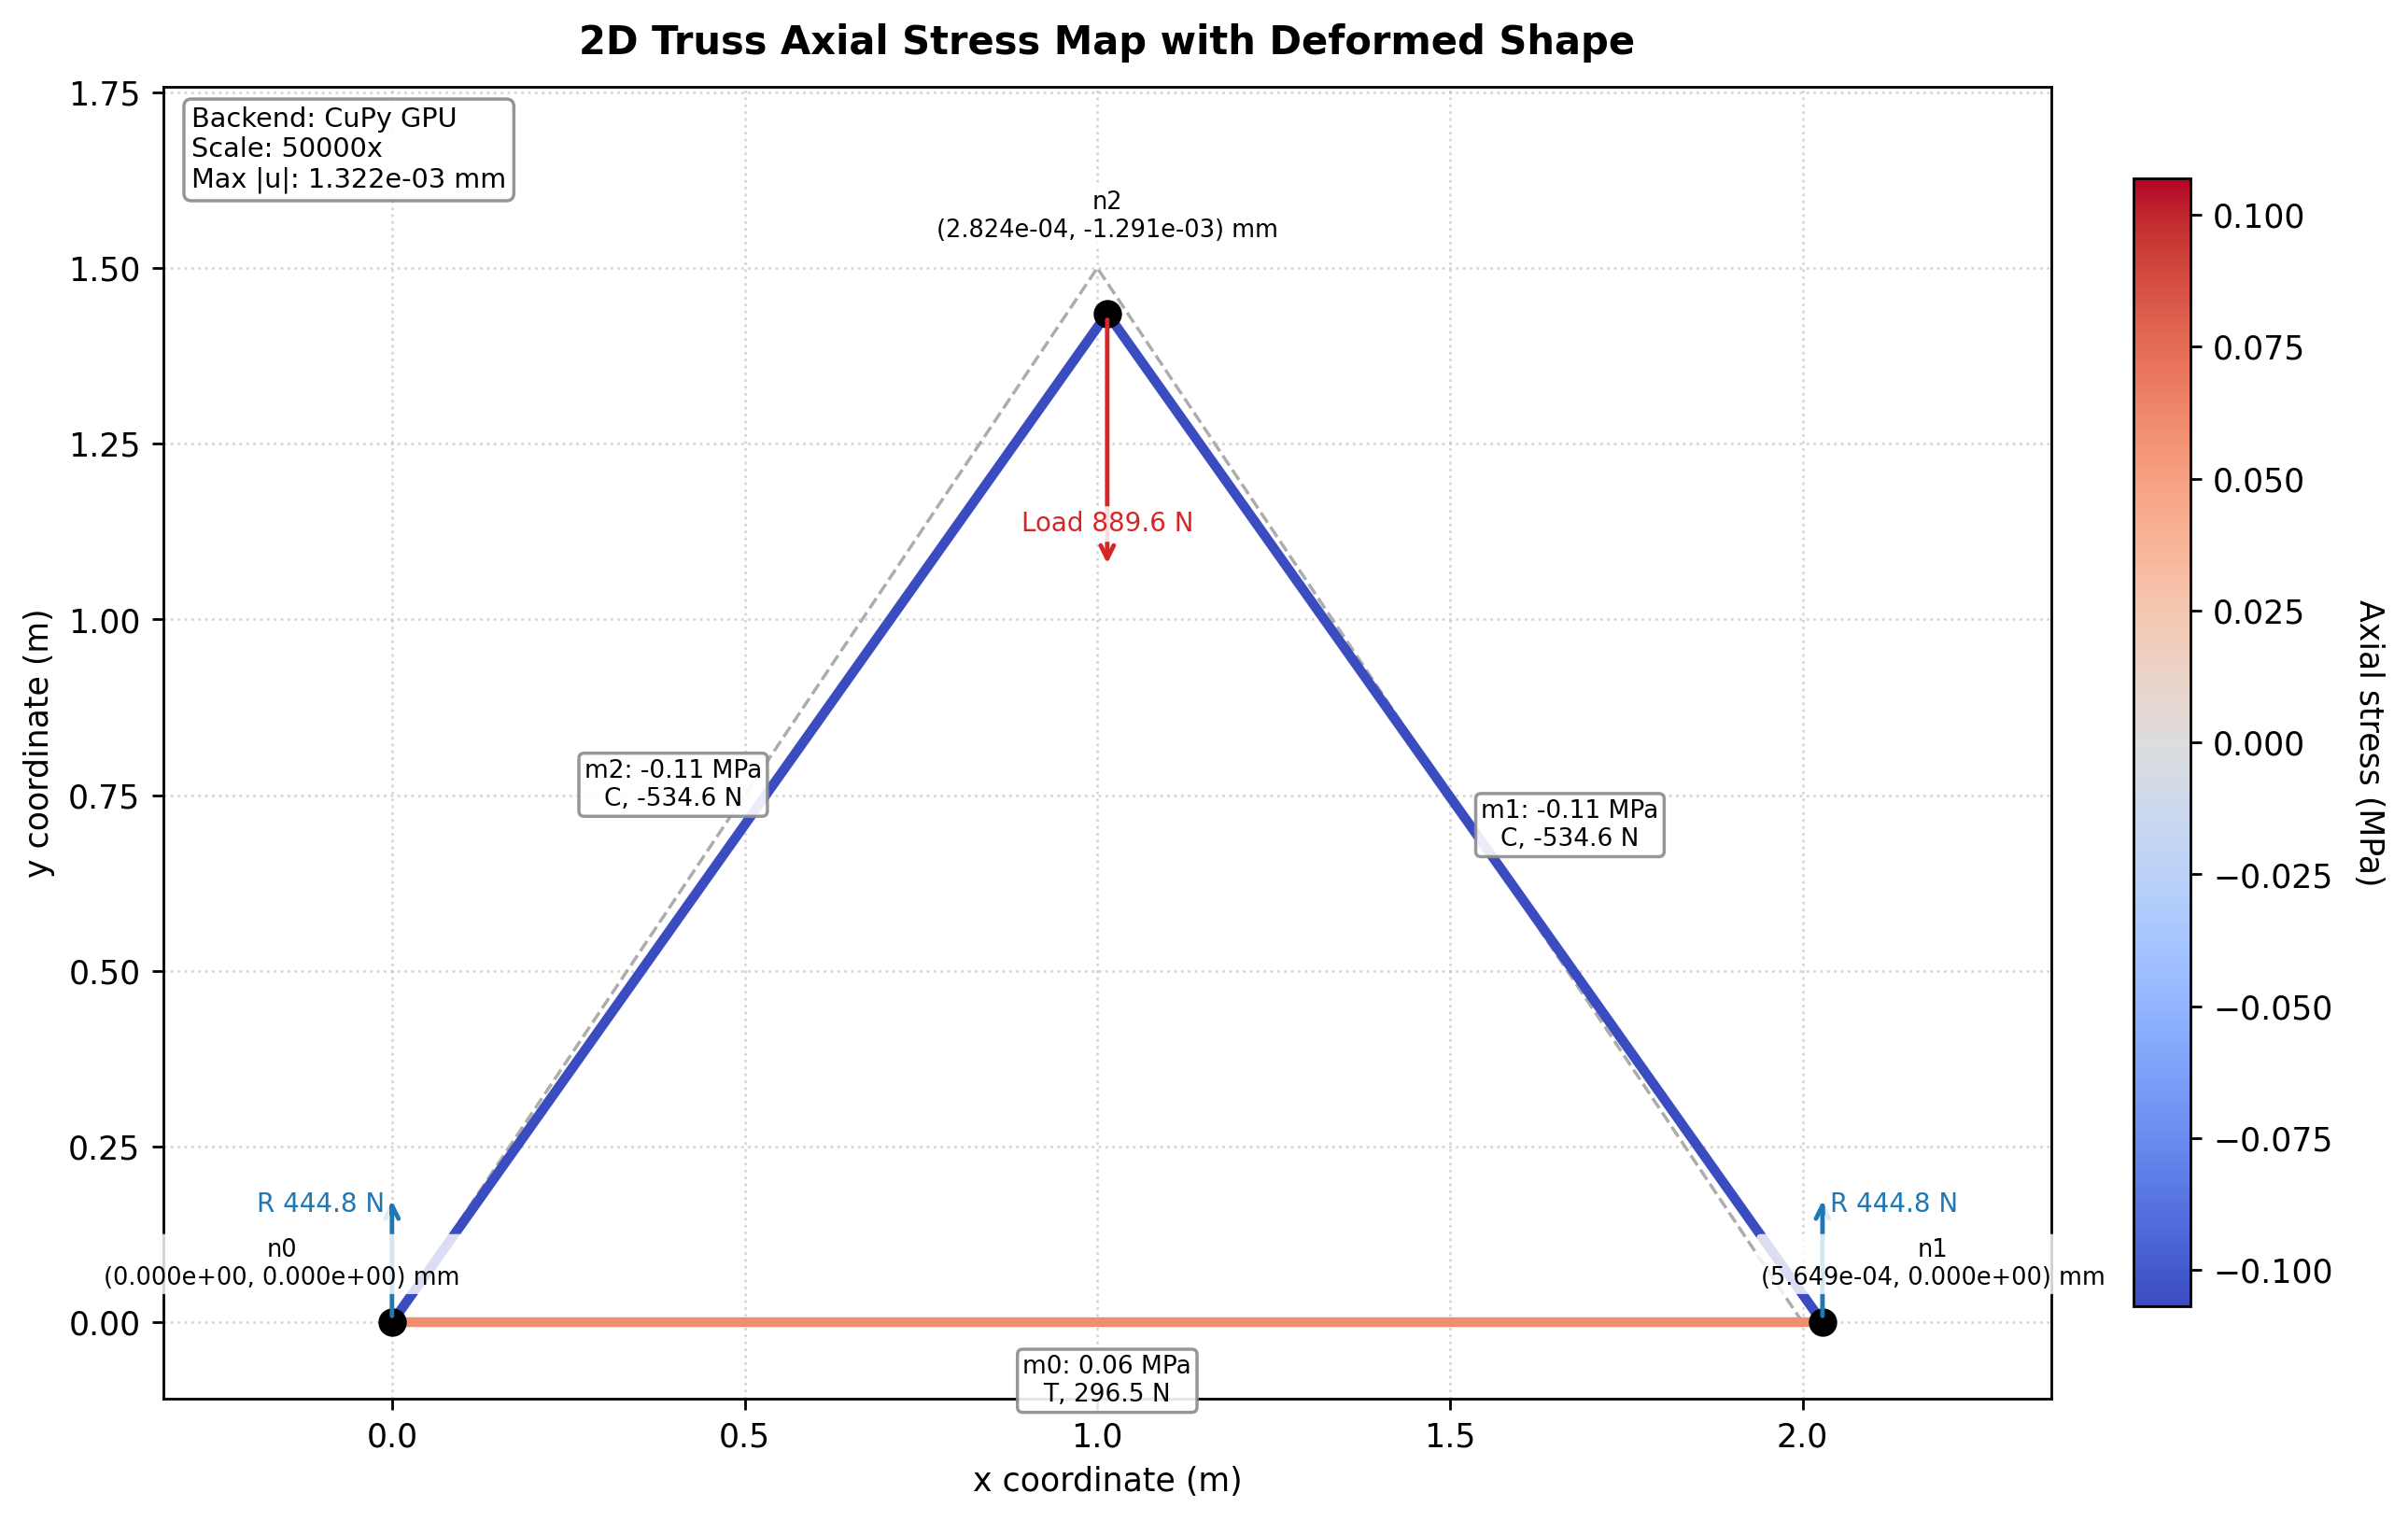

In [3]:
"""2D truss finite-element heat map.

This script solves a small planar truss with the direct stiffness method,
then renders a stress heat map with deformation, reaction forces, applied
loads, node labels, member labels, and tabulated diagnostics.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import cupy as cp
except ImportError:
    cp = None


# =============================================================================
# CONTROL KNOBS
# =============================================================================
INSTALL_NOTE = "!uv pip install -q numpy pandas matplotlib cupy-cuda12x"

USE_GPU_WHEN_AVAILABLE = True
MPL_DPI = 250

YOUNGS_MODULUS_PA = 210.0e9
CROSS_AREA_M2 = 0.005
YIELD_STRENGTH_PA = 250.0e6

LBS_TO_NEWTONS = 4.44822
NODE_2_LOAD_X_N = 0.0
NODE_2_LOAD_Y_N = -200.0 * LBS_TO_NEWTONS

DEFORMATION_SCALE = 50_000.0
FIGURE_SIZE = (9.5, 6.2)
BASE_MEMBER_LINEWIDTH = 3.0
MEMBER_LINEWIDTH_GAIN = 5.0
NODE_MARKER_SIZE = 60
ANNOTATE_MEMBERS = True
ANNOTATE_NODES = True
ANNOTATE_LOADS_AND_REACTIONS = True
SHOW_UNDEFORMED_REFERENCE = True

STRESS_UNIT_SCALE = 1.0e-6
STRESS_UNIT_LABEL = "MPa"

DISPLACEMENT_UNIT_SCALE = 1.0e3
DISPLACEMENT_UNIT_LABEL = "mm"

ROUND_DIGITS = 5
# =============================================================================


def select_array_backend() -> tuple[Any, bool]:
    """Return CuPy when available and requested, otherwise return NumPy."""
    if USE_GPU_WHEN_AVAILABLE is False or cp is None:
        return np, False

    try:
        device_count = cp.cuda.runtime.getDeviceCount()
    except cp.cuda.runtime.CUDARuntimeError:
        return np, False

    if device_count < 1:
        return np, False

    return cp, True


XP, USING_CUPY = select_array_backend()


@dataclass(frozen=True)
class TrussInput:
    """Container for material parameters, geometry, supports, and loads."""

    youngs_modulus_pa: float
    cross_area_m2: float
    yield_strength_pa: float
    nodes_m: np.ndarray
    elements: np.ndarray
    fixed_dofs: tuple[int, ...]
    nodal_loads_n: dict[int, tuple[float, float]]


@dataclass(frozen=True)
class TrussResult:
    """Container for solved truss quantities."""

    displacements_m: np.ndarray
    reactions_n: np.ndarray
    element_lengths_m: np.ndarray
    element_angles_rad: np.ndarray
    element_strains: np.ndarray
    element_stresses_pa: np.ndarray
    element_axial_forces_n: np.ndarray
    global_residual_n: np.ndarray


def to_numpy(array: Any) -> np.ndarray:
    """Convert a NumPy or CuPy array to a NumPy array."""
    if USING_CUPY:
        return cp.asnumpy(array)
    return np.asarray(array)


def build_default_model() -> TrussInput:
    """Build the default three-member triangular truss model."""
    nodes_m = np.array(
        [
            [0.0, 0.0],
            [2.0, 0.0],
            [1.0, 1.5],
        ],
        dtype=np.float64,
    )
    elements = np.array(
        [
            [0, 1],
            [1, 2],
            [0, 2],
        ],
        dtype=np.int64,
    )
    nodal_loads_n = {
        2: (NODE_2_LOAD_X_N, NODE_2_LOAD_Y_N),
    }

    return TrussInput(
        youngs_modulus_pa=YOUNGS_MODULUS_PA,
        cross_area_m2=CROSS_AREA_M2,
        yield_strength_pa=YIELD_STRENGTH_PA,
        nodes_m=nodes_m,
        elements=elements,
        fixed_dofs=(0, 1, 3),
        nodal_loads_n=nodal_loads_n,
    )


def local_truss_stiffness(
    youngs_modulus_pa: float,
    cross_area_m2: float,
    length_m: float,
    cosine: float,
    sine: float,
    xp: Any,
) -> Any:
    """Compute a 2D truss element stiffness matrix in global coordinates."""
    transform_matrix = xp.array(
        [
            [cosine**2, cosine * sine, -(cosine**2), -cosine * sine],
            [cosine * sine, sine**2, -cosine * sine, -(sine**2)],
            [-(cosine**2), -cosine * sine, cosine**2, cosine * sine],
            [-cosine * sine, -(sine**2), cosine * sine, sine**2],
        ],
        dtype=xp.float64,
    )
    coefficient = youngs_modulus_pa * cross_area_m2 / length_m
    return coefficient * transform_matrix


def element_dof_indices(node_i: int, node_j: int) -> list[int]:
    """Return global displacement indices for a two-node truss element."""
    return [
        2 * node_i,
        2 * node_i + 1,
        2 * node_j,
        2 * node_j + 1,
    ]


def assemble_global_stiffness(model: TrussInput, xp: Any) -> tuple[Any, Any, Any]:
    """Assemble the global stiffness matrix and element geometry arrays."""
    nodes = xp.asarray(model.nodes_m, dtype=xp.float64)
    elements = model.elements

    total_dof = 2 * len(model.nodes_m)
    num_elements = len(elements)

    k_global = xp.zeros((total_dof, total_dof), dtype=xp.float64)
    element_lengths = xp.zeros(num_elements, dtype=xp.float64)
    element_angles = xp.zeros(num_elements, dtype=xp.float64)

    for elem_idx, (node_i, node_j) in enumerate(elements):
        x_i, y_i = nodes[int(node_i)]
        x_j, y_j = nodes[int(node_j)]

        dx = x_j - x_i
        dy = y_j - y_i
        length = xp.sqrt(dx**2 + dy**2)
        angle = xp.arctan2(dy, dx)

        cosine = dx / length
        sine = dy / length

        k_local = local_truss_stiffness(
            model.youngs_modulus_pa,
            model.cross_area_m2,
            length,
            cosine,
            sine,
            xp,
        )
        dofs = element_dof_indices(int(node_i), int(node_j))

        for local_i, global_i in enumerate(dofs):
            for local_j, global_j in enumerate(dofs):
                k_global[global_i, global_j] += k_local[local_i, local_j]

        element_lengths[elem_idx] = length
        element_angles[elem_idx] = angle

    return k_global, element_lengths, element_angles


def build_force_vector(model: TrussInput, xp: Any) -> Any:
    """Build the global nodal force vector."""
    total_dof = 2 * len(model.nodes_m)
    forces = xp.zeros(total_dof, dtype=xp.float64)

    for node_index, (force_x, force_y) in model.nodal_loads_n.items():
        forces[2 * node_index] = force_x
        forces[2 * node_index + 1] = force_y

    return forces


def solve_truss(model: TrussInput) -> TrussResult:
    """Solve the truss displacements, stresses, member forces, and reactions."""
    xp = XP
    k_global, lengths, angles = assemble_global_stiffness(model, xp)
    forces = build_force_vector(model, xp)

    total_dof = 2 * len(model.nodes_m)
    all_dofs = set(range(total_dof))
    free_dofs = tuple(sorted(all_dofs.difference(model.fixed_dofs)))

    k_reduced = k_global[xp.ix_(free_dofs, free_dofs)]
    f_reduced = forces[list(free_dofs)]
    u_reduced = xp.linalg.solve(k_reduced, f_reduced)

    displacements = xp.zeros(total_dof, dtype=xp.float64)
    for idx, free_dof in enumerate(free_dofs):
        displacements[free_dof] = u_reduced[idx]

    strains = xp.zeros(len(model.elements), dtype=xp.float64)
    stresses = xp.zeros(len(model.elements), dtype=xp.float64)
    axial_forces = xp.zeros(len(model.elements), dtype=xp.float64)

    for elem_idx, (node_i, node_j) in enumerate(model.elements):
        node_i = int(node_i)
        node_j = int(node_j)
        angle = angles[elem_idx]
        cosine = xp.cos(angle)
        sine = xp.sin(angle)

        transform = xp.array(
            [-cosine, -sine, cosine, sine],
            dtype=xp.float64,
        )
        dofs = element_dof_indices(node_i, node_j)
        element_displacement = displacements[dofs]

        strains[elem_idx] = xp.dot(transform, element_displacement) / lengths[
            elem_idx
        ]
        stresses[elem_idx] = model.youngs_modulus_pa * strains[elem_idx]
        axial_forces[elem_idx] = stresses[elem_idx] * model.cross_area_m2

    residual = k_global @ displacements - forces
    reactions = residual.copy()

    return TrussResult(
        displacements_m=to_numpy(displacements).reshape((-1, 2)),
        reactions_n=to_numpy(reactions).reshape((-1, 2)),
        element_lengths_m=to_numpy(lengths),
        element_angles_rad=to_numpy(angles),
        element_strains=to_numpy(strains),
        element_stresses_pa=to_numpy(stresses),
        element_axial_forces_n=to_numpy(axial_forces),
        global_residual_n=to_numpy(residual),
    )


def build_element_table(model: TrussInput, result: TrussResult) -> pd.DataFrame:
    """Build a member-level diagnostic table."""
    stress_abs = np.abs(result.element_stresses_pa)
    safety_factor = np.divide(
        model.yield_strength_pa,
        stress_abs,
        out=np.full_like(stress_abs, np.inf, dtype=np.float64),
        where=stress_abs > 0.0,
    )
    utilization = stress_abs / model.yield_strength_pa

    states = np.where(
        result.element_axial_forces_n > 0.0,
        "Tension",
        np.where(result.element_axial_forces_n < 0.0, "Compression", "Neutral"),
    )

    return pd.DataFrame(
        {
            "Member": np.arange(len(model.elements)),
            "Nodes": [f"{i}-{j}" for i, j in model.elements],
            "Length (m)": result.element_lengths_m,
            "Angle (deg)": np.degrees(result.element_angles_rad),
            "Axial force (N)": result.element_axial_forces_n,
            f"Stress ({STRESS_UNIT_LABEL})": (
                result.element_stresses_pa * STRESS_UNIT_SCALE
            ),
            "Strain (microstrain)": result.element_strains * 1.0e6,
            "Utilization (-)": utilization,
            "Safety factor (-)": safety_factor,
            "State": states,
        }
    ).round(ROUND_DIGITS)


def build_node_table(model: TrussInput, result: TrussResult) -> pd.DataFrame:
    """Build a node-level displacement, load, and reaction table."""
    loads = np.zeros_like(result.reactions_n)

    for node_index, (force_x, force_y) in model.nodal_loads_n.items():
        loads[node_index, 0] = force_x
        loads[node_index, 1] = force_y

    displacement_magnitude = np.linalg.norm(result.displacements_m, axis=1)
    support_state = []
    fixed_dof_set = set(model.fixed_dofs)

    for node_idx in range(len(model.nodes_m)):
        x_fixed = (2 * node_idx) in fixed_dof_set
        y_fixed = (2 * node_idx + 1) in fixed_dof_set
        support_state.append(f"Ux fixed={x_fixed}, Uy fixed={y_fixed}")

    return pd.DataFrame(
        {
            "Node": np.arange(len(model.nodes_m)),
            "x (m)": model.nodes_m[:, 0],
            "y (m)": model.nodes_m[:, 1],
            f"Ux ({DISPLACEMENT_UNIT_LABEL})": (
                result.displacements_m[:, 0] * DISPLACEMENT_UNIT_SCALE
            ),
            f"Uy ({DISPLACEMENT_UNIT_LABEL})": (
                result.displacements_m[:, 1] * DISPLACEMENT_UNIT_SCALE
            ),
            f"|u| ({DISPLACEMENT_UNIT_LABEL})": (
                displacement_magnitude * DISPLACEMENT_UNIT_SCALE
            ),
            "Applied Fx (N)": loads[:, 0],
            "Applied Fy (N)": loads[:, 1],
            "Reaction Rx (N)": result.reactions_n[:, 0],
            "Reaction Ry (N)": result.reactions_n[:, 1],
            "Support": support_state,
        }
    ).round(ROUND_DIGITS)


def add_vector_annotation(
    ax: plt.Axes,
    start_xy: np.ndarray,
    vector_xy: np.ndarray,
    label: str,
    scale: float,
    color: str,
    text_offset_points: tuple[float, float] = (0.0, 0.0),
) -> None:
    """Add a scaled force-vector arrow and a readable label."""
    vector_norm = np.linalg.norm(vector_xy)
    if vector_norm <= 0.0:
        return

    end_xy = start_xy + scale * vector_xy
    ax.annotate(
        "",
        xy=end_xy,
        xytext=start_xy,
        arrowprops={
            "arrowstyle": "->",
            "color": color,
            "linewidth": 1.4,
            "shrinkA": 2,
            "shrinkB": 2,
        },
        zorder=7,
    )

    label_xy = start_xy + 0.72 * scale * vector_xy
    ax.annotate(
        label,
        xy=label_xy,
        xytext=text_offset_points,
        textcoords="offset points",
        color=color,
        fontsize=8,
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.86,
        },
        zorder=8,
    )


def get_member_label_position(
    start_xy: np.ndarray,
    end_xy: np.ndarray,
    member_index: int,
    span: float,
) -> tuple[np.ndarray, tuple[float, float]]:
    """Return a member label anchor and point offset for clean placement."""
    midpoint = 0.5 * (start_xy + end_xy)

    member_offsets = {
        0: (midpoint, (0.0, -18.0)),
        1: (0.52 * start_xy + 0.48 * end_xy, (28.0, 4.0)),
        2: (0.48 * start_xy + 0.52 * end_xy, (-28.0, 4.0)),
    }

    if member_index in member_offsets:
        return member_offsets[member_index]

    tangent = end_xy - start_xy
    tangent_norm = np.linalg.norm(tangent)

    if tangent_norm <= 0.0:
        return midpoint, (0.0, 0.0)

    normal = np.array([-tangent[1], tangent[0]]) / tangent_norm
    anchor = midpoint + 0.035 * span * normal
    return anchor, (0.0, 0.0)


def get_node_label_offset(node_index: int) -> tuple[float, float]:
    """Return point offsets for node labels."""
    node_offsets = {
        0: (-34.0, 18.0),
        1: (34.0, 18.0),
        2: (0.0, 30.0),
    }
    return node_offsets.get(node_index, (0.0, 22.0))


def set_padded_limits(
    ax: plt.Axes,
    original_nodes: np.ndarray,
    deformed_nodes: np.ndarray,
    padding_fraction: float = 0.16,
) -> None:
    """Set axis limits with enough padding for labels and arrows."""
    all_nodes = np.vstack([original_nodes, deformed_nodes])
    x_min, y_min = np.min(all_nodes, axis=0)
    x_max, y_max = np.max(all_nodes, axis=0)

    x_span = max(x_max - x_min, 1.0)
    y_span = max(y_max - y_min, 1.0)

    ax.set_xlim(
        x_min - padding_fraction * x_span,
        x_max + padding_fraction * x_span,
    )
    ax.set_ylim(
        y_min - 0.12 * y_span,
        y_max + 0.22 * y_span,
    )


def render_truss_heatmap(model: TrussInput, result: TrussResult) -> None:
    """Render a cleaner truss stress heat map with managed label placement."""
    mpl.rcParams["figure.dpi"] = MPL_DPI

    nodes = model.nodes_m
    elements = model.elements
    deformed_nodes = nodes + DEFORMATION_SCALE * result.displacements_m

    element_stresses_plot = result.element_stresses_pa * STRESS_UNIT_SCALE
    max_abs_stress = np.max(np.abs(element_stresses_plot))
    stress_limit = max(max_abs_stress, 1.0e-12)

    norm = mcolors.TwoSlopeNorm(
        vmin=-stress_limit,
        vcenter=0.0,
        vmax=stress_limit,
    )
    cmap = cm.coolwarm

    fig, ax = plt.subplots(figsize=(10.2, 6.4), constrained_layout=True)

    if SHOW_UNDEFORMED_REFERENCE:
        for node_i, node_j in elements:
            node_i = int(node_i)
            node_j = int(node_j)
            ax.plot(
                [nodes[node_i, 0], nodes[node_j, 0]],
                [nodes[node_i, 1], nodes[node_j, 1]],
                color="0.68",
                linestyle="--",
                linewidth=1.0,
                zorder=1,
            )

    utilization = np.abs(result.element_stresses_pa) / model.yield_strength_pa
    plot_span = max(np.ptp(deformed_nodes[:, 0]), np.ptp(deformed_nodes[:, 1]), 1.0)

    for elem_idx, (node_i, node_j) in enumerate(elements):
        node_i = int(node_i)
        node_j = int(node_j)

        member_width = (
            BASE_MEMBER_LINEWIDTH
            + MEMBER_LINEWIDTH_GAIN * float(utilization[elem_idx])
        )
        member_width = min(member_width, 8.0)

        start_xy = deformed_nodes[node_i]
        end_xy = deformed_nodes[node_j]
        color = cmap(norm(element_stresses_plot[elem_idx]))

        ax.plot(
            [start_xy[0], end_xy[0]],
            [start_xy[1], end_xy[1]],
            color=color,
            linewidth=member_width,
            solid_capstyle="round",
            zorder=3,
        )

        if ANNOTATE_MEMBERS:
            force_n = result.element_axial_forces_n[elem_idx]
            state = "T" if force_n >= 0.0 else "C"
            stress_mpa = result.element_stresses_pa[elem_idx] * STRESS_UNIT_SCALE
            label = (
                f"m{elem_idx}: {stress_mpa:.2f} {STRESS_UNIT_LABEL}\n"
                f"{state}, {force_n:.1f} N"
            )
            anchor_xy, offset_points = get_member_label_position(
                start_xy,
                end_xy,
                elem_idx,
                plot_span,
            )
            ax.annotate(
                label,
                xy=anchor_xy,
                xytext=offset_points,
                textcoords="offset points",
                fontsize=7.6,
                ha="center",
                va="center",
                bbox={
                    "boxstyle": "round,pad=0.22",
                    "facecolor": "white",
                    "edgecolor": "0.55",
                    "alpha": 0.90,
                },
                zorder=6,
            )

    ax.scatter(
        deformed_nodes[:, 0],
        deformed_nodes[:, 1],
        color="black",
        s=NODE_MARKER_SIZE,
        zorder=5,
    )

    if ANNOTATE_NODES:
        for node_idx, xy in enumerate(deformed_nodes):
            ux_mm = result.displacements_m[node_idx, 0] * 1.0e3
            uy_mm = result.displacements_m[node_idx, 1] * 1.0e3
            offset_points = get_node_label_offset(node_idx)

            ax.annotate(
                f"n{node_idx}\n({ux_mm:.3e}, {uy_mm:.3e}) mm",
                xy=xy,
                xytext=offset_points,
                textcoords="offset points",
                fontsize=7.4,
                ha="center",
                va="center",
                bbox={
                    "boxstyle": "round,pad=0.16",
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.82,
                },
                zorder=8,
            )

    if ANNOTATE_LOADS_AND_REACTIONS:
        force_vectors = []

        for force_xy in model.nodal_loads_n.values():
            force_vectors.append(np.asarray(force_xy, dtype=np.float64))

        for node_idx in range(len(nodes)):
            force_vectors.append(result.reactions_n[node_idx])

        max_force = max([np.linalg.norm(vec) for vec in force_vectors] + [1.0])
        vector_scale = 0.18 * plot_span / max_force

        for node_idx, force_xy in model.nodal_loads_n.items():
            add_vector_annotation(
                ax=ax,
                start_xy=deformed_nodes[node_idx],
                vector_xy=np.asarray(force_xy, dtype=np.float64),
                label=f"Load {np.linalg.norm(force_xy):.1f} N",
                scale=vector_scale,
                color="tab:red",
                text_offset_points=(0.0, -8.0),
            )

        fixed_nodes = sorted({dof // 2 for dof in model.fixed_dofs})
        reaction_label_offsets = {
            0: (-22.0, 8.0),
            1: (22.0, 8.0),
        }

        for node_idx in fixed_nodes:
            reaction_xy = result.reactions_n[node_idx]
            add_vector_annotation(
                ax=ax,
                start_xy=deformed_nodes[node_idx],
                vector_xy=reaction_xy,
                label=f"R {np.linalg.norm(reaction_xy):.1f} N",
                scale=vector_scale,
                color="tab:blue",
                text_offset_points=reaction_label_offsets.get(
                    node_idx,
                    (0.0, 8.0),
                ),
            )

    scalar_map = cm.ScalarMappable(cmap=cmap, norm=norm)
    scalar_map.set_array([])
    cbar = fig.colorbar(scalar_map, ax=ax, pad=0.015, shrink=0.86)
    cbar.set_label(
        f"Axial stress ({STRESS_UNIT_LABEL})",
        rotation=270,
        labelpad=16,
    )

    max_disp_mm = (
        np.max(np.linalg.norm(result.displacements_m, axis=1))
        * DISPLACEMENT_UNIT_SCALE
    )

    ax.text(
        0.015,
        0.985,
        (
            f"Backend: {'CuPy GPU' if USING_CUPY else 'NumPy CPU'}\n"
            f"Scale: {DEFORMATION_SCALE:.0f}x\n"
            f"Max |u|: {max_disp_mm:.3e} {DISPLACEMENT_UNIT_LABEL}"
        ),
        transform=ax.transAxes,
        fontsize=8.3,
        ha="left",
        va="top",
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "white",
            "edgecolor": "0.55",
            "alpha": 0.92,
        },
        zorder=10,
    )

    ax.set_title(
        "2D Truss Axial Stress Map with Deformed Shape",
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("x coordinate (m)")
    ax.set_ylabel("y coordinate (m)")
    ax.grid(True, linestyle=":", alpha=0.50)
    ax.axis("equal")
    set_padded_limits(ax, nodes, deformed_nodes)

    plt.show()


def print_diagnostics(model: TrussInput, result: TrussResult) -> None:
    """Print tables and equilibrium diagnostics."""
    element_table = build_element_table(model, result)
    node_table = build_node_table(model, result)

    total_applied_load = np.zeros(2, dtype=np.float64)
    for force_xy in model.nodal_loads_n.values():
        total_applied_load += np.asarray(force_xy, dtype=np.float64)

    total_reaction = np.sum(result.reactions_n, axis=0)
    equilibrium_error = total_applied_load + total_reaction

    total_dof = 2 * len(model.nodes_m)
    free_dofs = sorted(set(range(total_dof)).difference(model.fixed_dofs))
    fixed_dofs = sorted(model.fixed_dofs)
    free_residual_norm = np.linalg.norm(result.global_residual_n[free_dofs])
    fixed_reaction_norm = np.linalg.norm(result.global_residual_n[fixed_dofs])

    print(f"Install note: {INSTALL_NOTE}")
    print(f"Backend: {'CuPy GPU' if USING_CUPY else 'NumPy CPU'}")
    print("\nElement diagnostics")
    print(element_table.to_string(index=False))
    print("\nNode diagnostics")
    print(node_table.to_string(index=False))
    print("\nEquilibrium checks")
    print(f"  Sum applied loads [Fx, Fy] (N): {total_applied_load}")
    print(f"  Sum reactions [Rx, Ry] (N): {total_reaction}")
    print(f"  Force balance error [Fx, Fy] (N): {equilibrium_error}")
    print(f"  Free DOF residual norm (N): {free_residual_norm:.6e}")
    print(f"  Support reaction vector norm (N): {fixed_reaction_norm:.6e}")


def main() -> tuple[TrussInput, TrussResult]:
    """Run the truss analysis workflow and render the heat map."""
    mpl.rcParams["figure.dpi"] = MPL_DPI

    model = build_default_model()
    result = solve_truss(model)

    print_diagnostics(model, result)
    render_truss_heatmap(model, result)

    return model, result


if __name__ == "__main__":
    truss_model, truss_result = main()